In [15]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [16]:
# =========================
# 2. CREATE SYNTHETIC STOCK MARKET DATA
# =========================

# Reproducibility
np.random.seed(42)

# Simulate 365 trading days
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')

# -------------------------
# COMPONENTS OF STOCK PRICE
# -------------------------

# A gradual bullish trend
trend = np.linspace(100, 180, 365)

# Monthly market cycle (seasonality)
seasonal = 8 * np.sin(2 * np.pi * dates.dayofyear / 30)

# Random market volatility/noise
noise = np.random.normal(0, 3, 365)

# Combine all components
stock_price = trend + seasonal + noise

# Create DataFrame
df = pd.DataFrame({
    'Close_Price': stock_price
}, index=dates)


In [17]:
# =========================
# 3. DISPLAY BASIC DATA
# =========================

print("\n==============================")
print("STOCK MARKET DATA (FIRST 5 ROWS)")
print("==============================")
print(df.head())


STOCK MARKET DATA (FIRST 5 ROWS)
            Close_Price
2024-01-01   103.153436
2024-01-02   103.058880
2024-01-03   107.084908
2024-01-04   111.173589
2024-01-05   107.104864


In [18]:
# =========================
# 4. STATIONARITY TEST
# =========================

# Augmented Dickey-Fuller Test
def check_stationarity(series):

    result = adfuller(series)

    print("\n==============================")
    print("ADF STATIONARITY TEST")
    print("==============================")

    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')

    if result[1] <= 0.05:
        print("Result : Stationary Time Series")
    else:
        print("Result : Non-Stationary Time Series")

# Execute test
check_stationarity(df['Close_Price'])


ADF STATIONARITY TEST
ADF Statistic : -0.1742
p-value       : 0.9415
Result : Non-Stationary Time Series


In [19]:
# =========================
# 5. TIME SERIES DECOMPOSITION
# =========================

# Decompose into:
# Trend + Seasonal + Residual

decomposition = seasonal_decompose(
    df['Close_Price'],
    model='additive',
    period=30
)

# Extract components
df_components = pd.DataFrame({
    'Observed': decomposition.observed,
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
})


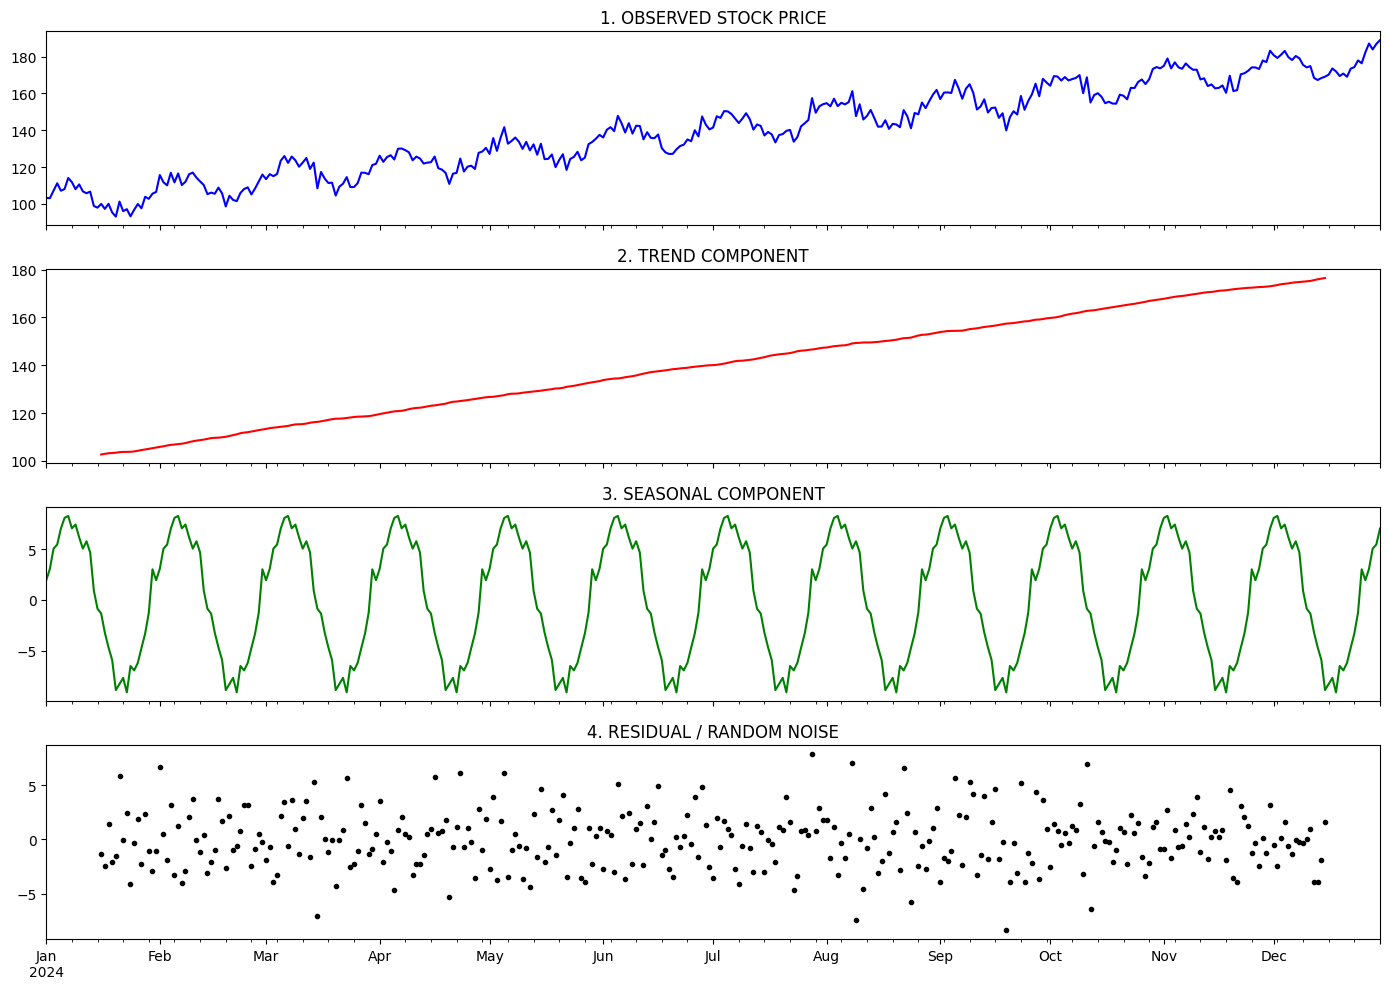

In [20]:
# =========================
# 6. VISUALIZATION OF COMPONENTS
# =========================

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# -------------------------
# Original Stock Price
# -------------------------
df_components['Observed'].plot(
    ax=axes[0],
    color='blue',
    title='1. OBSERVED STOCK PRICE'
)

# -------------------------
# Trend Component
# -------------------------
df_components['Trend'].plot(
    ax=axes[1],
    color='red',
    title='2. TREND COMPONENT'
)

# -------------------------
# Seasonal Component
# -------------------------
df_components['Seasonal'].plot(
    ax=axes[2],
    color='green',
    title='3. SEASONAL COMPONENT'
)

# -------------------------
# Residual Component
# -------------------------
df_components['Residual'].plot(
    ax=axes[3],
    color='black',
    style='.',
    title='4. RESIDUAL / RANDOM NOISE'
)

plt.tight_layout()
plt.show()

In [21]:
# =========================
# 7. TRAIN-TEST SPLIT
# =========================

# Use 80% data for training
train_size = int(len(df) * 0.80)

train_data = df['Close_Price'][:train_size]
test_data = df['Close_Price'][train_size:]

print("\n==============================")
print("TRAIN TEST SPLIT")
print("==============================")
print(f"Training Data Size : {len(train_data)}")
print(f"Testing Data Size  : {len(test_data)}")


TRAIN TEST SPLIT
Training Data Size : 292
Testing Data Size  : 73


In [22]:
# =========================
# 8. BUILD ARIMA MODEL
# =========================

# ARIMA(p,d,q)
# p = autoregression
# d = differencing
# q = moving average

model = ARIMA(train_data, order=(5, 1, 2))

# Train the model
model_fit = model.fit()

print("\n==============================")
print("ARIMA MODEL SUMMARY")
print("==============================")
print(model_fit.summary())



ARIMA MODEL SUMMARY
                               SARIMAX Results                                
Dep. Variable:            Close_Price   No. Observations:                  292
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -775.977
Date:                Fri, 08 May 2026   AIC                           1567.954
Time:                        23:09:00   BIC                           1597.340
Sample:                    01-01-2024   HQIC                          1579.726
                         - 10-18-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1813      0.068     17.411      0.000       1.048       1.314
ar.L2          0.0277      0.100      0.278      0.781      -0.168       0.223
ar.L3          0.0103      0.09

In [23]:
# =========================
# 9. STOCK PRICE FORECASTING
# =========================

# Predict future values
predictions = model_fit.forecast(steps=len(test_data))

In [24]:
# =========================
# 10. MODEL EVALUATION
# =========================

rmse = np.sqrt(mean_squared_error(test_data, predictions))

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")
print(f'RMSE : {rmse:.4f}')


MODEL PERFORMANCE
RMSE : 10.9924


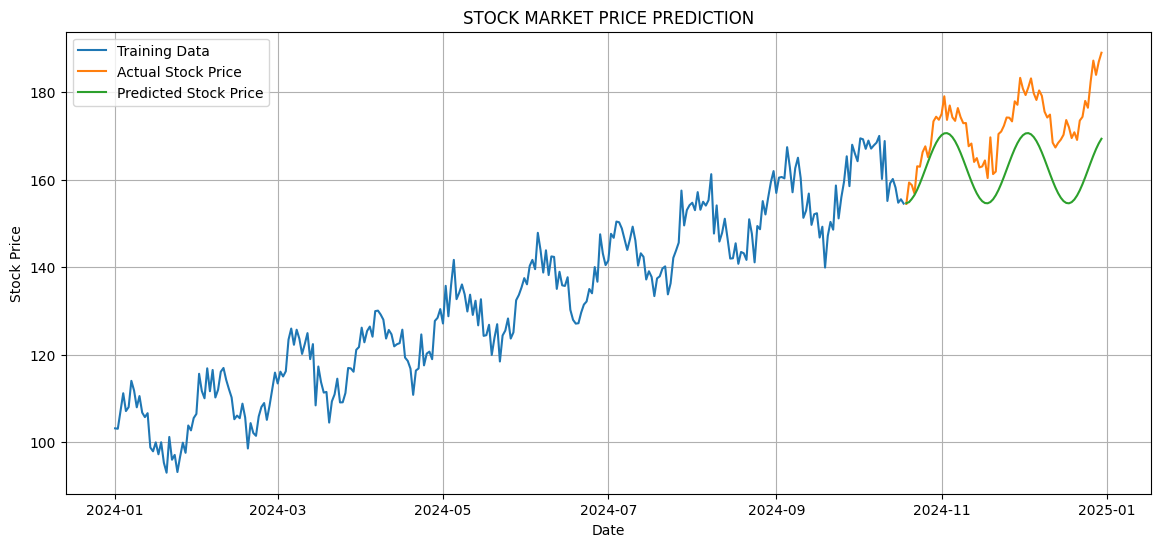

In [25]:
# =========================
# 11. VISUALIZE PREDICTIONS
# =========================

plt.figure(figsize=(14, 6))

# Actual prices
plt.plot(
    train_data.index,
    train_data,
    label='Training Data'
)

plt.plot(
    test_data.index,
    test_data,
    label='Actual Stock Price'
)

# Predicted prices
plt.plot(
    test_data.index,
    predictions,
    label='Predicted Stock Price'
)

plt.title('STOCK MARKET PRICE PREDICTION')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()

plt.grid(True)
plt.show()

In [26]:
# =========================
# 12. FUTURE FORECAST
# =========================

# Predict next 30 days
future_forecast = model_fit.forecast(steps=30)

future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

future_df = pd.DataFrame({
    'Future_Predicted_Price': future_forecast
}, index=future_dates)

print("\n==============================")
print("NEXT 30 DAYS FORECAST")
print("==============================")
print(future_df)



NEXT 30 DAYS FORECAST
            Future_Predicted_Price
2024-12-31                     NaN
2025-01-01                     NaN
2025-01-02                     NaN
2025-01-03                     NaN
2025-01-04                     NaN
2025-01-05                     NaN
2025-01-06                     NaN
2025-01-07                     NaN
2025-01-08                     NaN
2025-01-09                     NaN
2025-01-10                     NaN
2025-01-11                     NaN
2025-01-12                     NaN
2025-01-13                     NaN
2025-01-14                     NaN
2025-01-15                     NaN
2025-01-16                     NaN
2025-01-17                     NaN
2025-01-18                     NaN
2025-01-19                     NaN
2025-01-20                     NaN
2025-01-21                     NaN
2025-01-22                     NaN
2025-01-23                     NaN
2025-01-24                     NaN
2025-01-25                     NaN
2025-01-26                     N

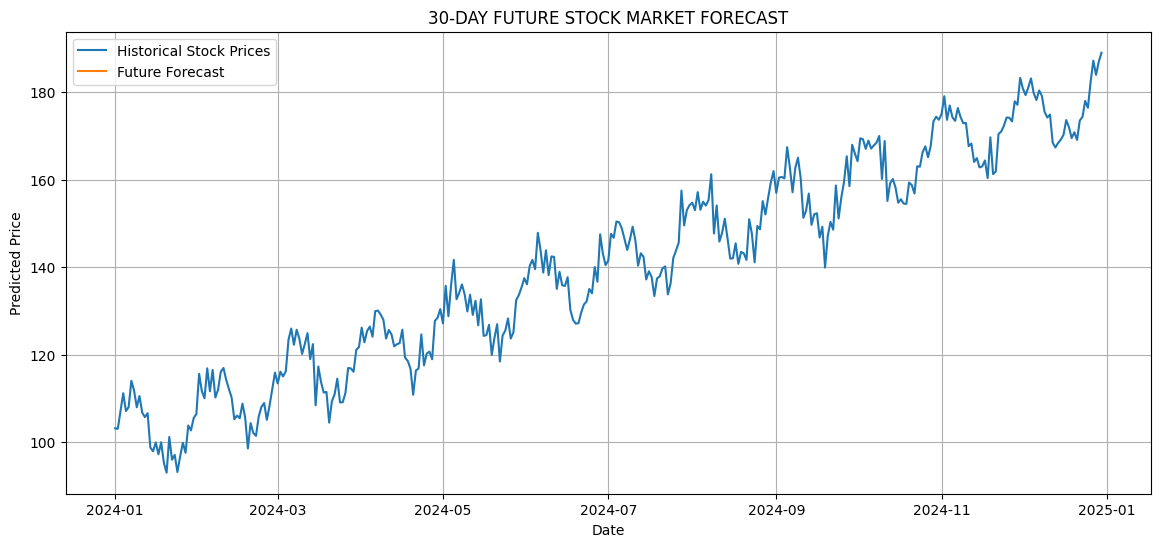

In [27]:
# =========================
# 13. FUTURE FORECAST VISUALIZATION
# =========================

plt.figure(figsize=(14, 6))

# Historical data
plt.plot(
    df.index,
    df['Close_Price'],
    label='Historical Stock Prices'
)

# Future forecast
plt.plot(
    future_df.index,
    future_df['Future_Predicted_Price'],
    label='Future Forecast'
)

plt.title('30-DAY FUTURE STOCK MARKET FORECAST')
plt.xlabel('Date')
plt.ylabel('Predicted Price')

plt.legend()
plt.grid(True)

plt.show()


In [28]:
# =========================
# 14. FINAL OUTPUT TABLE
# =========================

print("\n==============================")
print("DECOMPOSITION TABLE (FIRST 5 ROWS)")
print("==============================")

print(df_components.head())

print("\n==============================")
print("LAB COMPLETED SUCCESSFULLY")
print("==============================")


DECOMPOSITION TABLE (FIRST 5 ROWS)
              Observed  Trend  Seasonal  Residual
2024-01-01  103.153436    NaN  1.942623       NaN
2024-01-02  103.058880    NaN  3.062748       NaN
2024-01-03  107.084908    NaN  5.047998       NaN
2024-01-04  111.173589    NaN  5.456923       NaN
2024-01-05  107.104864    NaN  7.024027       NaN

LAB COMPLETED SUCCESSFULLY
